## Roughness scaling: analysis

- Loads the pre-computed slimmed summary produced by `roughness_scale-load-compute`. 
- All large simulation arrays (hc, vc, veg …) have been dropped.

Key points this notebook:
- The effect size increases with sigma, but not monotonically with fV

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import os as _os
import sys
import shutil
import itertools as it
import contextlib
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler
import statsmodels.formula.api as smf
import json
from scipy.stats import gmean
import pandas as pd

sys.path.append("/Users/octaviacrompton/Projects/roughness-scale/swof_code")


import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

In [ ]:
# ── Figure registry (src/figure_registry.py) ──────────────────────────────────
import sys as _sys
_sys.path.insert(0, "/Users/octaviacrompton/Projects/roughness-scale/src")
import figure_registry as _fig_reg

# Expose convenience names so all figure-saving cells work unchanged
_fig_dirs              = _fig_reg._fig_dirs
update_figure_registry = _fig_reg.update_figure_registry

# Note: call _fig_reg.configure(out_dir) once out_dir is set (see data-load cell)

In [ ]:
my_modules = ['plot_SWOF', "read_SWOF", "write_SWOF", 
              "plot_config", "topo", "source_functions_1p3"]

for mod in my_modules:
    if mod in sys.modules: 
        del sys.modules[mod] 

from plot_SWOF import *
from read_SWOF import *
from plot_config import *
from topo import *
from write_SWOF import *
from source_functions_1p3 import *


In [ ]:
project_dir = "/Users/octaviacrompton/Dropbox/FullCSWOF/Tests/"
cases = [d for d in os.listdir(project_dir) if 
            ('DS_Store' not in d) and ('figures' not in d)]


In [ ]:

# out_dir must match what was used in roughness_scale-load-compute
out_dir   = os.path.join(project_dir, 'runaround_smooth')
slim_path = os.path.join(out_dir, 'summary_slim.pkl')

summary = pd.read_pickle(slim_path)
print(f'Loaded summary_slim: shape = {summary.shape}')
print('Columns:', sorted(summary.columns.tolist()))

# initialise figure registry for this session
_fig_reg.configure(out_dir, notebook_name='roughness_scale-analysis.ipynb')

In [85]:
# ── Variable naming / display labels ──────────────────────────────────────────
# Shared labels, colour maps, and helpers live in src/labels.py
import sys as _sys
_sys.path.insert(0, "/Users/octaviacrompton/Projects/roughness-scale/src")
from labels import (
    updates, rename, renameit,
    VEG_COLORS, VEG_LABELS,
    FS_LABEL, FS_TITLE, FS_TICK, FS_LEG,
    VAR_CMAPS,
    format_name as _format_name_raw,
)

# Wrap format_name so callers don't need to pass `names` explicitly
def format_name(fld, updates=updates):
    return _format_name_raw(fld, names, updates=updates)

summary['LB_std'] = [l.std() for l in summary.LB_dist]

# ── Toggle: set USE_HYDRO = True to make 'effect_ratio' use hydrograph-based n_e
USE_HYDRO = False
if USE_HYDRO:
    summary['effect']       = summary['effect_hydro']
    summary['effect_ratio'] = summary['effect_ratio_hydro']


Text(0, 0.5, 'Discharge (mm/hr)')

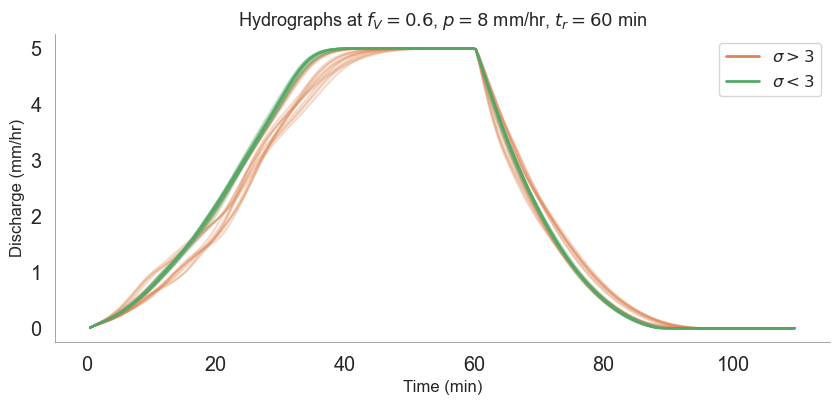

In [86]:

fig, ax = plt.subplots(1, figsize = (10,4))

from matplotlib.lines import Line2D

subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV == 0.6 and sigma >3  ")
plot_hydrographs(subset, c= 'C1', ax =ax)

subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV == 0.6 and sigma <3 ")
plot_hydrographs(subset, c= 'C2', ax =ax)

# Legend & title
ax.legend(handles=[
    Line2D([0], [0], color='C1', lw=2, label=r'$\sigma > 3$'),
    Line2D([0], [0], color='C2', lw=2, label=r'$\sigma < 3$'),
], fontsize=FS_LEG)
ax.set_title(r"Hydrographs at $f_V=0.6$, $p=8$ mm/hr, $t_r=60$ min", fontsize=FS_TITLE)
ax.set_xlabel("Time (min)", fontsize=FS_LABEL)
ax.set_ylabel("Discharge (mm/hr)", fontsize=FS_LABEL)


0.6
0.95


Text(0, 0.5, 'Discharge (mm/hr)')

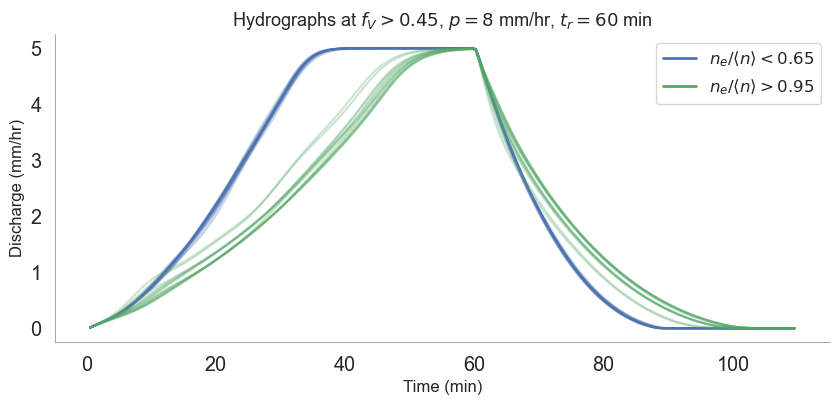

In [87]:
fig, ax = plt.subplots(1, figsize = (10,4))

from matplotlib.lines import Line2D

subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV > 0.45 and effect_ratio < 0.65 ")
plot_hydrographs(subset, c= 'C0', ax =ax)
print ((subset.fV.max()))

subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV > 0.45 and  effect_ratio > 0.95 ")
plot_hydrographs(subset, c= 'C2', ax =ax)
print ((subset.fV.max()))

# Legend & title
ax.legend(handles=[
    Line2D([0], [0], color='C0', lw=2, label=r'$n_e/\langle n \rangle < 0.65$'),
    Line2D([0], [0], color='C2', lw=2, label=r'$n_e/\langle n \rangle > 0.95$'),
], fontsize=FS_LEG)
ax.set_title(r"Hydrographs at $f_V > 0.45$, $p=8$ mm/hr, $t_r=60$ min", fontsize=FS_TITLE)
ax.set_xlabel("Time (min)", fontsize=FS_LABEL)
ax.set_ylabel("Discharge (mm/hr)", fontsize=FS_LABEL)

##  Spatial pattern 


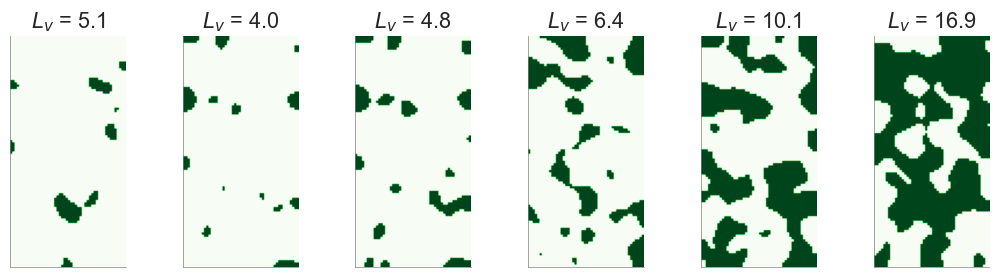

In [88]:
if 'veg_type' in summary.columns and (summary['veg_type'] == 'blob').any():
    fig, axes = plt.subplots(1,6,figsize = (13, 3) )
    axes = axes.ravel()
    for i, key in enumerate(summary.query("L > 10 and L < 500 and sigma == 3 and aniso == 1 and veg_type == 'blob'").sort_values('fV').index[::10][:6]):
        sim = summary.loc[key]
        axes[ i].imshow(sim.veg.T[:100], cmap = "Greens")
        axes[i].imshow(sim.veg.T[:100], cmap = "Greens")

        bin_max = np.maximum(sim.LB_dist.max(), sim.L_dc_dist.max())

        axes[i].set_xticks([])
        axes[i].set_yticks([])
        axes[i].set_title("$L_v$ = {0:.1f}".format(sim.LV))


## Illustrate calibration

In [89]:
def plot_q_compare(sim, ax):
    """Plot hydrograph comparison: avg-n discharge vs equivalent-n discharge.
    Gracefully skips series that are missing from the slimmed summary."""
    # Use .get() so missing columns don't raise AttributeError on a pandas Series row
    t       = sim.get('t')           if hasattr(sim, 'get') else getattr(sim, 't',          None)
    hydro   = sim.get('hydro')       if hasattr(sim, 'get') else getattr(sim, 'hydro',      None)
    eq_hyd  = sim.get('equiv_hydro') if hasattr(sim, 'get') else getattr(sim, 'equiv_hydro',None)
    r_avg_v   = sim.get('r_avg',   sim.get('<n>',          None)) if hasattr(sim, 'get') else None
    r_equiv_v = sim.get('r_equiv', sim.get('effect_ratio', None)) if hasattr(sim, 'get') else None

    plotted = False
    if t is not None and hydro is not None:
        lbl = r"$\langle n \rangle$" + (r"$={:.2f}$".format(r_avg_v) if r_avg_v is not None else "")
        ax.plot(t / 60, hydro, label=lbl)
        plotted = True
    if t is not None and eq_hyd is not None:
        lbl = r"$n_e$" + (r"$={:.2f}$".format(r_equiv_v) if r_equiv_v is not None else "")
        ax.plot(t[:len(eq_hyd)] / 60, eq_hyd, label=lbl)
        plotted = True
    if not plotted:
        ax.text(0.5, 0.5, "hydrograph data\nnot in slim summary",
                ha='center', va='center', transform=ax.transAxes, fontsize=9, color='grey')
        ax.set_axis_off()
    else:
        ax.legend()
        ax.set_xlabel("time (min)")
        ax.set_ylabel("discharge")

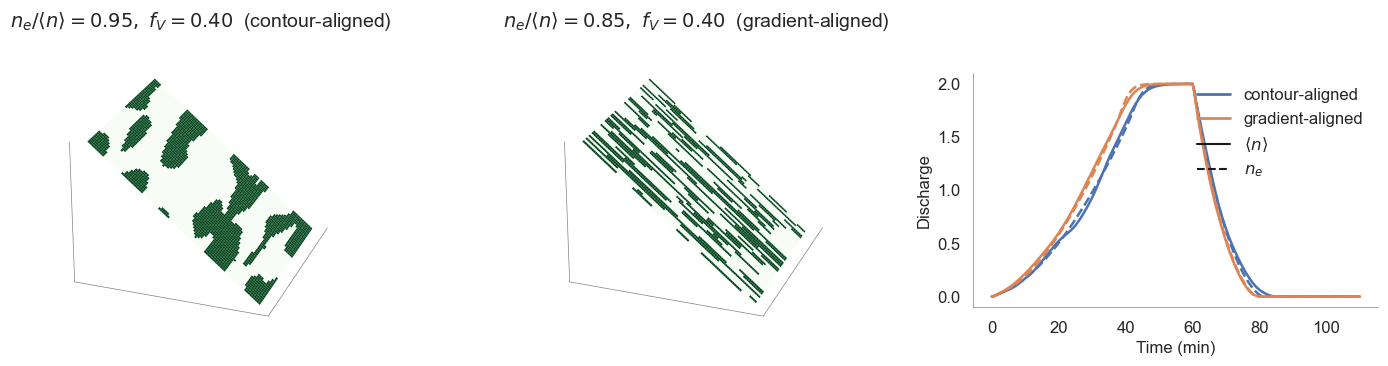

In [90]:
query = 'hydro_err < 0.02'
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

sim_a = summary.query(query).query(" sigma == 5 and aniso > 1 and tr == 60  and fV > 0.3").iloc[0]
sim_b = summary.query(query).query("sigma == 5 and aniso < 0 and tr == 60 and fV > 0.3").iloc[0]

# Use explicit axes positions so all three panels share the same bounding box
fig = plt.figure(figsize=(15, 4))

_left   = [0.03, 0.36, 0.68]
_w, _h, _b = 0.27, 0.78, 0.10

ax1 = fig.add_axes([_left[0], _b, _w, _h], projection='3d')
ax2 = fig.add_axes([_left[1], _b, _w, _h], projection='3d')
ax3 = fig.add_axes([_left[2], _b*2, _w, _h*0.75])

# ── Panel 1: 3D veg surface, contour-aligned (aniso > 0) ──────────────────────
plot_surface(
    sim_a, 'veg',
    title=r"$n_e/\langle n\rangle={:.2f},\ f_V={:.2f}$  (contour-aligned)".format(
        sim_a.effect_ratio_geom, sim_a.veg.mean()),
    color=cm.Greens,
    ax=ax1, ucut=1, dcut=0, alpha=1.0, plot_veg=False,
)

# ── Panel 2: 3D veg surface, gradient-aligned (aniso < 0) ─────────────────────
plot_surface(
    sim_b, 'veg',
    title=r"$n_e/\langle n\rangle={:.2f},\ f_V={:.2f}$  (gradient-aligned)".format(
        sim_b.effect_ratio_geom, sim_b.veg.mean()),
    color=cm.Greens,
    ax=ax2, ucut=1, dcut=0, alpha=1.0, plot_veg=False,
)

# ── Panel 3: combined hydrographs (linestyle = method, color = simulation) ────
_colors = {'contour-aligned': 'C0', 'gradient-aligned': 'C1'}

for sim, label in [(sim_a, 'contour-aligned'), (sim_b, 'gradient-aligned')]:
    t      = sim.get('t')
    hydro  = sim.get('hydro')
    eq_hyd = sim.get('equiv_hydro')
    c = _colors[label]
    if t is not None and hydro is not None:
        ax3.plot(t / 60, hydro, color=c, linestyle='-', lw=1.8)
    if t is not None and eq_hyd is not None:
        ax3.plot(t[:len(eq_hyd)] / 60, eq_hyd, color=c, linestyle='--', lw=1.8)

# Legend: colour = simulation, linestyle = quantity
_legend_handles = [
    Line2D([0], [0], color=_colors['contour-aligned'], lw=2, label='contour-aligned'),
    Line2D([0], [0], color=_colors['gradient-aligned'], lw=2, label='gradient-aligned'),
    Line2D([0], [0], color='k', lw=1.5, linestyle='-',  label=r'$\langle n\rangle$'),
    Line2D([0], [0], color='k', lw=1.5, linestyle='--', label=r'$n_e$'),
]
ax3.legend(handles=_legend_handles, frameon=False, fontsize=FS_LEG)
ax3.set_xlabel("Time (min)", fontsize=FS_LABEL)
ax3.set_ylabel("Discharge", fontsize=FS_LABEL)
ax3.tick_params(labelsize=FS_TICK)


0.0028779022479586388 0.0009702347431453948 2.966191705966738
0.0029131077311290118 0.0007696410103394473 3.7850214476541426


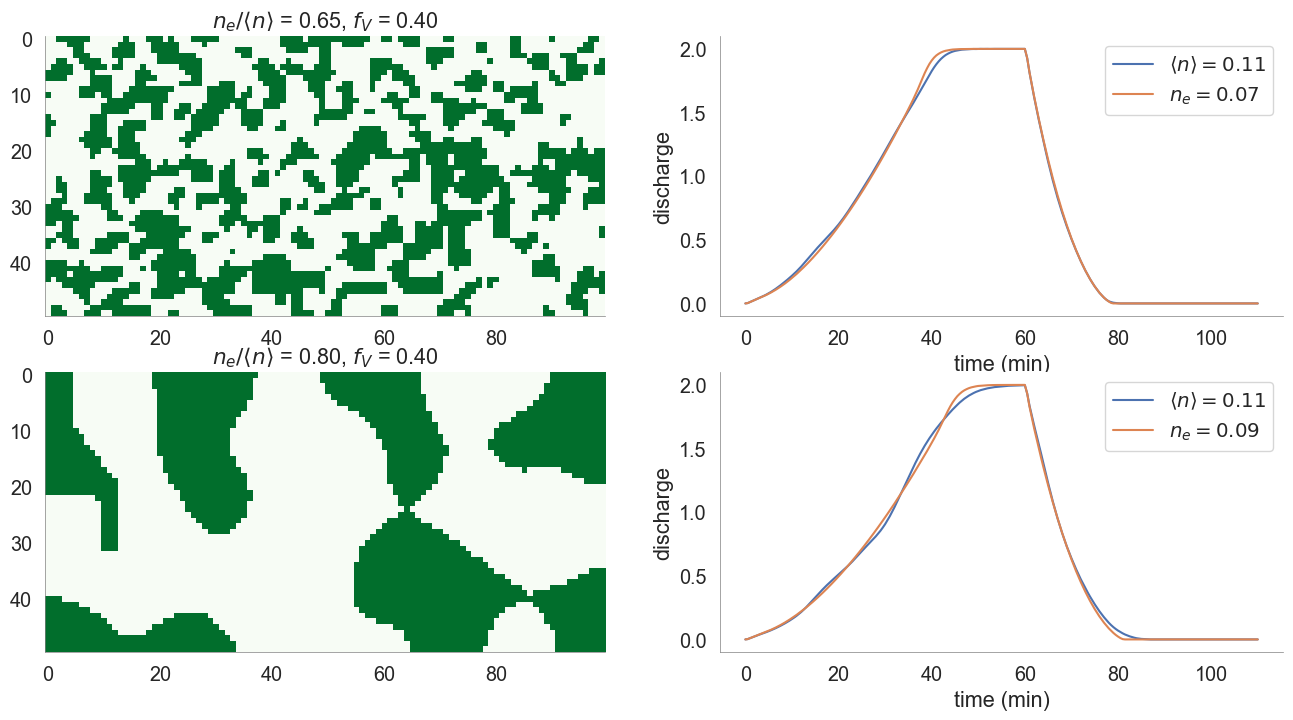

In [91]:
query = 'hydro_err < 0.03   and p == 5 and  l == 200 and tr == 60'
fig, axes = plt.subplots(2, 2, figsize = (16,8))
axes = axes.ravel()
sim = summary.query(query).query("fV > 0.3 and sigma == 1 and aniso == 1").iloc[0]
axes[0].imshow(sim.veg[:, :150], cmap = 'Greens', vmin = 0, vmax = 1.15)

axes[0].set_title(r"$n_e / \langle n \rangle$ = {0:.2f}, $f_V$ = {1:.2f}".format(sim.effect_ratio, sim.veg.mean()))
plot_q_compare(sim, axes[1])
print (sim['<U>']**2, sim['<Up2>'], sim['<U>']**2/sim['<Up2>'])

sim = summary.query(query).query("fV > 0.3 and sigma == 5 and aniso == 1 ").iloc[0]
axes[2].imshow(sim.veg[:, :150], cmap = 'Greens', vmin = 0, vmax = 1.15)
axes[2].set_title(r"$n_e / \langle n \rangle$ = {0:.2f}, $f_V$ = {1:.2f}".format(sim.effect_ratio, sim.veg.mean()))
print (sim['<U>']**2, sim['<Up2>'], sim['<U>']**2/sim['<Up2>'])

plot_q_compare(sim, axes[3])


0.0028779022479586388 0.0009702347431453948 2.966191705966738
0.0029131077311290118 0.0007696410103394473 3.7850214476541426


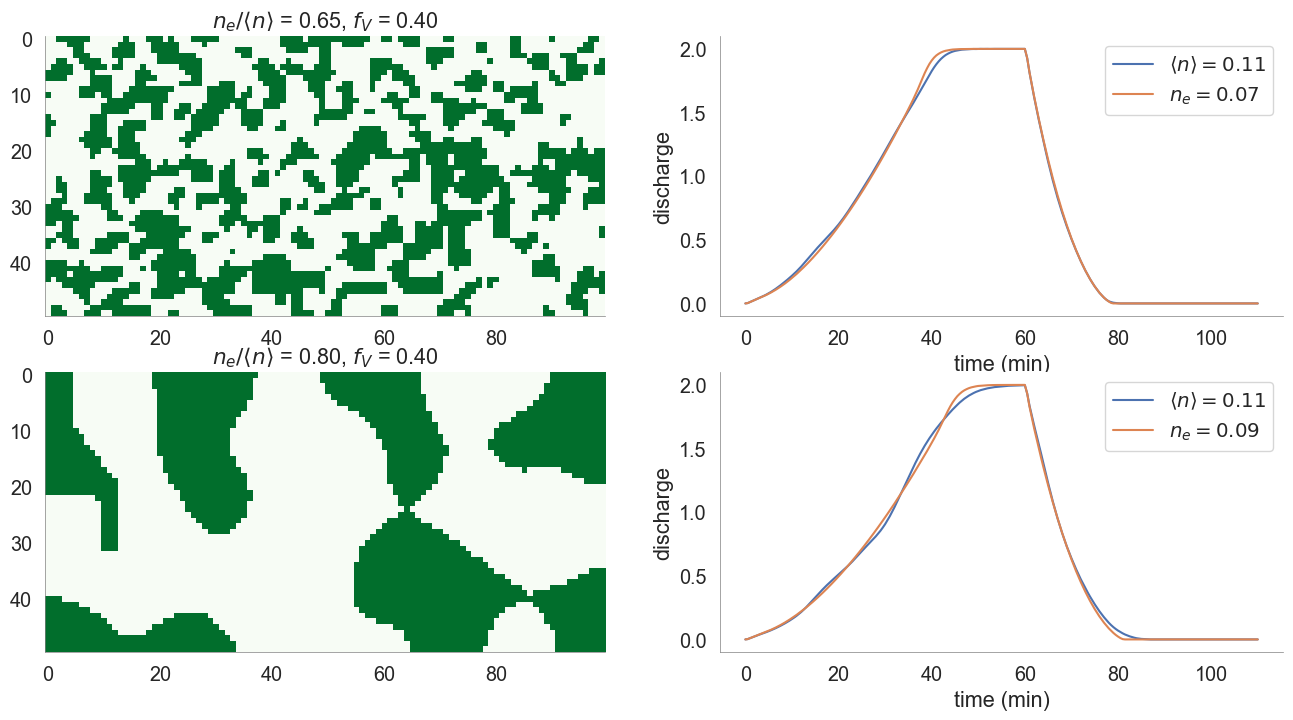

In [92]:
query = 'hydro_err < 0.03   and p == 5 and  l == 200 and tr == 60'
fig, axes = plt.subplots(2, 2, figsize = (16,8))
axes = axes.ravel()
sim = summary.query(query).query("fV > 0.3 and sigma == 1 and aniso == 1").iloc[0]
axes[0].imshow(sim.veg[:, :150], cmap = 'Greens', vmin = 0, vmax = 1.15)

axes[0].set_title(r"$n_e / \langle n \rangle$ = {0:.2f}, $f_V$ = {1:.2f}".format(sim.effect_ratio, sim.veg.mean()))
plot_q_compare(sim, axes[1])
print (sim['<U>']**2, sim['<Up2>'], sim['<U>']**2/sim['<Up2>'])

sim = summary.query(query).query("fV > 0.3 and sigma == 5 and aniso == 1 ").iloc[0]
axes[2].imshow(sim.veg[:, :150], cmap = 'Greens', vmin = 0, vmax = 1.15)
axes[2].set_title(r"$n_e / \langle n \rangle$ = {0:.2f}, $f_V$ = {1:.2f}".format(sim.effect_ratio, sim.veg.mean()))
print (sim['<U>']**2, sim['<Up2>'], sim['<U>']**2/sim['<Up2>'])

plot_q_compare(sim, axes[3])


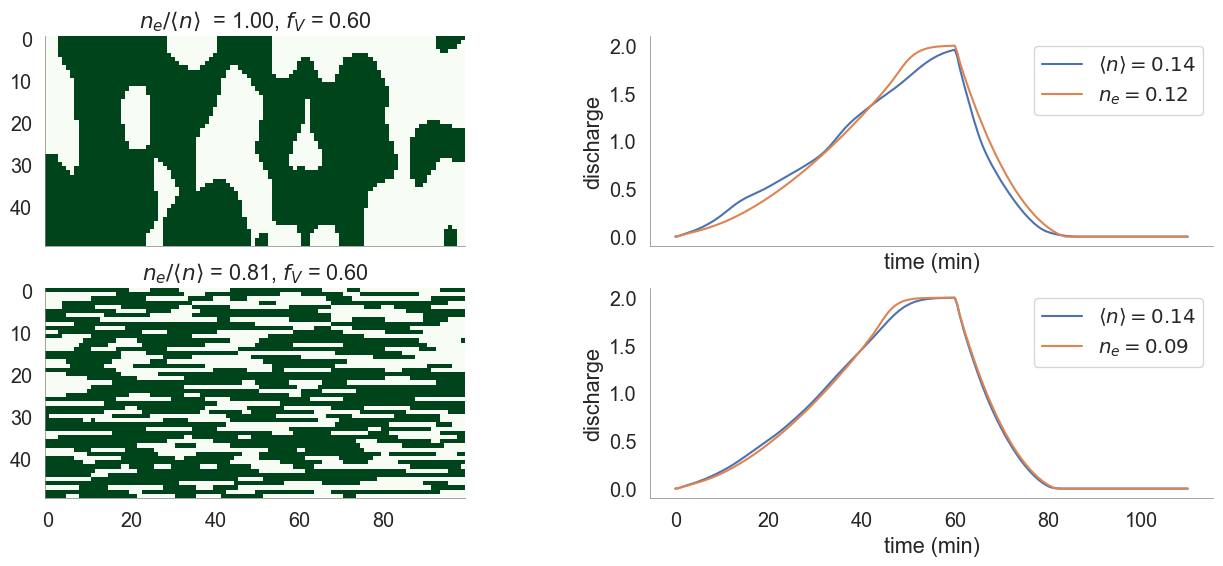

In [93]:
query = 'hydro_err < 0.05'
fig, axes = plt.subplots(2, 2, figsize = (16,6), sharex = 'col')
axes = axes.ravel()
sim = summary.query(query).query(" sigma == 5 and aniso > 0 and tr == 60  and fV > 0.4").iloc[0]
axes[0].imshow(sim.veg[:, :150], cmap = 'Greens')

axes[0].set_title(r"$n_e/\langle n \rangle $ " +" = {0:.2f}, $f_V$ = {1:.2f}".format(sim.effect_ratio_geom, sim.veg.mean()))
plot_q_compare(sim, axes[1])

sim = summary.query(query).query("sigma == 3 and aniso < 0 and tr == 60 and fV > 0.4").iloc[0]
axes[2].imshow(sim.veg[:, :150], cmap = 'Greens')

axes[2].set_title(r"$n_e/\langle n \rangle $ " + "= {0:.2f}, $f_V$ = {1:.2f}".format(sim.effect_ratio_geom, sim.veg.mean()))


plot_q_compare(sim, axes[3])
# the effect size increases with 


Text(0.5, 1.0, 'Cross-slope bands')

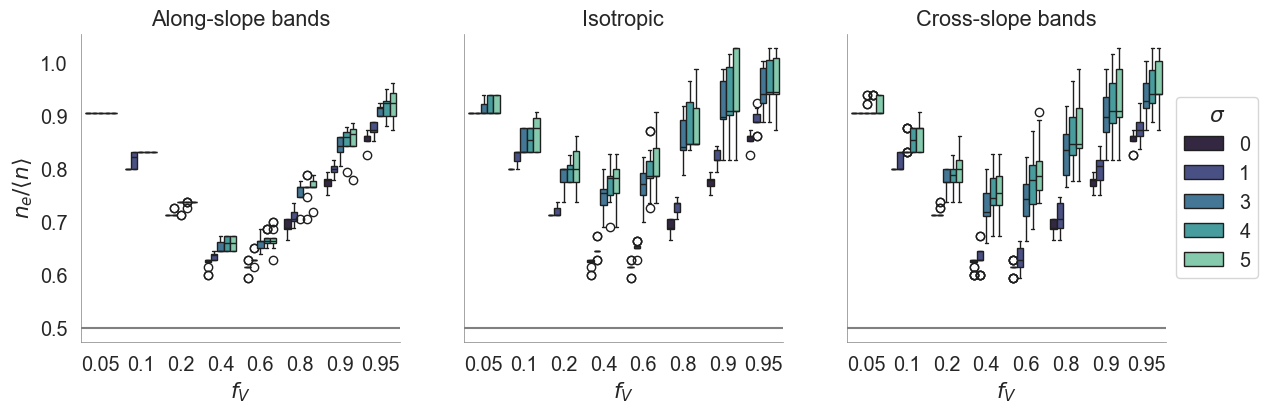

In [94]:
fig, axes = plt.subplots(1, 3, figsize = (14,4), sharey = True)

yfld = "effect_ratio"
xfld  = 'fV'
sfld = "sigma"
cfld = 'sigma'
summary['fV'] = summary['fV'].astype(float).round(2)
summary['sigma'] = summary['sigma'].astype(int)

query ='hydro_err < 0.1 and aniso < 0'
g = sns.boxplot(data = summary.query(query).rename(rename, axis = 1), 
                    x = rename[xfld], y = rename[yfld],  
                   hue = rename[cfld],  ax = axes[0],
                    palette = mako(len(summary.query(query)[cfld].unique()))
                   )
g.legend().set_visible(False)


query ='hydro_err < 0.1 and aniso == 1'
g = sns.boxplot(data = summary.query(query).rename(rename, axis = 1), 
                    x = rename[xfld], y = rename[yfld],  
                   hue = rename[cfld],  ax = axes[1],
                    palette = mako(len(summary.query(query)[cfld].unique())))
g.legend().set_visible(False)

query ='hydro_err < 0.1 and aniso >= 1'
g = sns.boxplot(data = summary.query(query).rename(rename, axis = 1), 
                    x = rename[xfld], y = rename[yfld],  
                   hue = rename[cfld],  ax = axes[2],
                    palette = mako(len(summary.query(query)[cfld].unique())))
g.legend(loc='center left',  bbox_to_anchor=(1.0, 0.5), ncol=1 , title = rename[cfld])    

axes[0].axhline(0.5, c = 'gray')
axes[1].axhline(0.5, c = 'gray')
axes[2].axhline(0.5, c = 'gray')
axes[0].set_title("Along-slope bands")
axes[1].set_title("Isotropic")
axes[2].set_title("Cross-slope bands")


In [95]:
_band_mask = summary['veg_type'].str.contains('band')
summary.loc[_band_mask, 'aniso'] = 1
summary.loc[_band_mask, 'stripe_count'] = summary.loc[_band_mask, 'l'] / summary.loc[_band_mask, 'sigma']
summary['effect_ratio_exp3'] = summary['n_exp3'] / summary['<n>']

_blob_mask = summary['veg_type'] == 'blob'
summary.loc[_blob_mask, 'stripe_count'] = summary.loc[_blob_mask, 'aniso']


In [96]:
# ── Parameters ────────────────────────────────────────────────────────────────
fV      = 0.6   # centre of fV window
fV_half = 0.05  # half-width → selects fV in [fV - fV_half, fV + fV_half]
hue_var = None  # None = auto: 'aniso' if only blobs, else 'veg_type'


def _build_hue_info(df, hue_var):
    """Return (plot_hue_col, palette, label_order, hue_label) for the given hue variable."""
    _veg_types = df['veg_type'].unique()
    if hue_var is None:
        hue_var = 'aniso' if set(_veg_types) == {'blob'} else 'veg_type'

    if hue_var == 'veg_type':
        palette = {k: v for k, v in VEG_COLORS.items() if k in _veg_types}
        _fallback = iter(_cm.tab10.colors)
        for vt in _veg_types:
            if vt not in palette:
                palette[vt] = next(_fallback)
        return hue_var, palette, None, 'veg type'

    if hue_var == 'aniso':
        _aniso_name = {v: ('gradient-aligned' if v < 0 else
                           'isotropic'        if v == 1 else
                           'contour-aligned') for v in sorted(df['aniso'].unique())}
        df['_aniso_label'] = df['aniso'].map(_aniso_name)
        _label_order = [l for l in ['gradient-aligned', 'isotropic', 'contour-aligned']
                        if l in df['_aniso_label'].unique()]
        _aniso_vals = sorted(_aniso_name.keys())
        _bg_cmap = _mcolors.LinearSegmentedColormap.from_list(
            'blue_green', ['#2166ac', '#92c5de', '#a6d96a', '#1a9641'])
        _norm = _mcolors.Normalize(vmin=min(_aniso_vals), vmax=max(_aniso_vals))
        palette = {_aniso_name[v]: _bg_cmap(_norm(v)) for v in _aniso_vals}
        return '_aniso_label', palette, _label_order, 'Orientation'

    return hue_var, 'viridis', None, hue_var


def _dedup_legend(handles, labels):
    """Return handles/labels with duplicate labels removed (keep first)."""
    seen, out_h, out_l = set(), [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); out_h.append(h); out_l.append(l)
    return out_h, out_l


# ── Filter + hue setup ────────────────────────────────────────────────────────
_df = summary[(summary['fV'] >= fV - fV_half) & (summary['fV'] <= fV + fV_half)].copy()

if _df.empty:
    print(f"No data in fV window [{fV - fV_half}, {fV + fV_half}]. "
          f"Available fV: {sorted(summary['fV'].unique())}")
else:
    _is_band    = _df['veg_type'].str.contains('band').any()
    _plot_hue, _palette, _label_order, _hue_label = _build_hue_info(_df, hue_var)

    _marker_pool = ['^', 'o', 's', 'D', 'P', 'X', 'v', '<', '>']
    _hue_vals    = list(_palette.keys()) if isinstance(_palette, dict) else sorted(_df[_plot_hue].unique())
    _markers     = {v: _marker_pool[i % len(_marker_pool)] for i, v in enumerate(_hue_vals)}


Registry updated → ../figures/runaround_smooth/figure_registry.txt  [fig3]


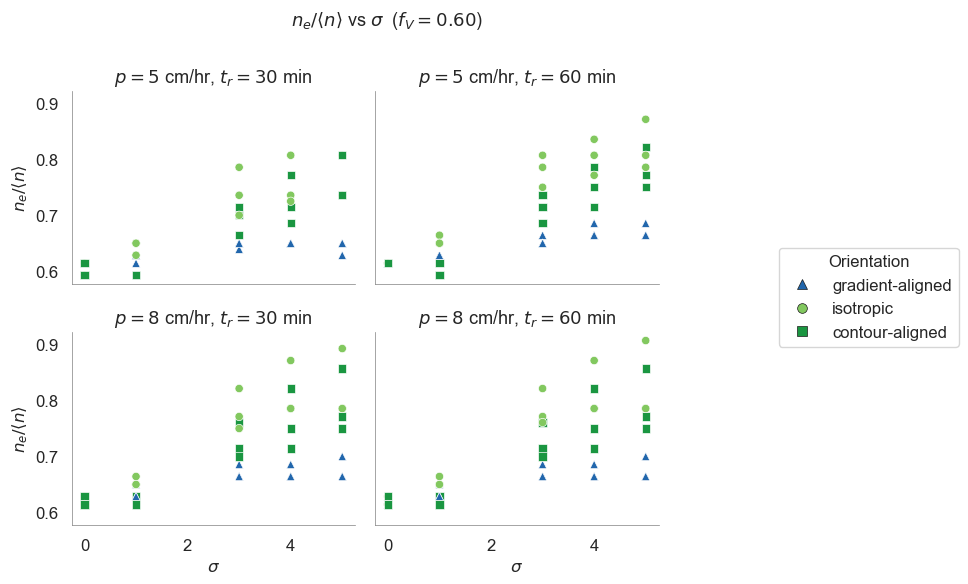

In [106]:
# ── Plot: effect_ratio vs sigma, faceted by (p, tr) ──────────────────────────
if not _df.empty:
    from matplotlib.lines import Line2D

    p_vals  = sorted(_df['p'].unique())
    tr_vals = sorted(_df['tr'].unique())
    nrows, ncols = len(p_vals), len(tr_vals)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows),
                             sharex=True, sharey=True)
    axes = np.array(axes).reshape(nrows, ncols)

    for ri, p in enumerate(p_vals):
        for ci, tr in enumerate(tr_vals):
            ax  = axes[ri, ci]
            sub = _df[(_df['p'] == p) & (_df['tr'] == tr)]
            if sub.empty:
                ax.set_visible(False)
                continue

            sns.scatterplot(
                data=sub,
                x='sigma', y='effect_ratio',
                hue=_plot_hue,
                style=_plot_hue,
                markers=_markers,
                palette=_palette,
                ax=ax,
                legend=False,
            )

            ax.set_title(f"$p={p}$ cm/hr, $t_r={tr}$ min", fontsize=FS_TITLE)
            ax.set_xlabel(("band count" if _is_band else r"$\sigma$") if ri == nrows - 1 else "",
                          fontsize=FS_LABEL)
            ax.set_ylabel(renameit('effect_ratio', rename) if ci == 0 else "", fontsize=FS_LABEL)
            ax.tick_params(labelsize=FS_TICK)

    # Figure-level legend
    _legend_values = _label_order if (_plot_hue == '_aniso_label' and _label_order is not None) else _hue_vals
    _legend_handles = []
    for v in _legend_values:
        _color = _palette[v] if isinstance(_palette, dict) else 'gray'
        _label = VEG_LABELS.get(v, v) if _plot_hue == 'veg_type' else v
        _legend_handles.append(
            Line2D([0], [0], marker=_markers[v], linestyle='None',
                   markerfacecolor=_color, markeredgecolor='k', markeredgewidth=0.5,
                   markersize=7, label=_label)
        )

    fig.legend(
        handles=_legend_handles,
        loc='center left',
        bbox_to_anchor=(0.98, 0.5),
        title=_hue_label,
        frameon=True,
        fontsize=FS_LEG,
        title_fontsize=FS_LEG,
    )

    fig.suptitle(
        fr"$n_e/\langle n \rangle$ vs $\sigma$  ($f_V = {fV:.2f}$)",
        fontsize=FS_TITLE,
    )
    plt.tight_layout()
    plt.subplots_adjust(right=0.84)

if not _df.empty:
    _fig_dir, _, _ = _fig_dirs()
    _name = 'fig3_effect_ratio_vs_sigma_grid.png'
    fig.savefig(_os.path.join(_fig_dir, _name), dpi=300, bbox_inches='tight')
    update_figure_registry(
        'fig3', _name,
        description=(
            r"$n_e/\langle n \rangle$ vs $\sigma$ for all simulations at "
            r"$f_V \approx 0.6$, organised in a grid of panels by rainfall intensity "
            r"($p$, rows) and storm duration ($t_r$, columns). "
            r"Points are coloured and shaped by vegetation arrangement type (or "
            r"anisotropy when only blob patterns are present)."
        ),
        concise=(
            r"Effect ratio vs sigma at fV≈0.6, panelled by p×tr, coloured by veg type / anisotropy. "
            r"Reveals how spatial heterogeneity (sigma) and storm forcing jointly "
            r"control the effective-roughness enhancement."
        ),
    )



Registry updated → ../figures/runaround_smooth/figure_registry.txt  [fig3]


In [ ]:

# sigma vs effect_ratio — one panel per fV value, 2 rows × 4 cols
# Interactive widget to toggle between storm cases (p, tr)
import ipywidgets as _widgets
from IPython.display import display as _display

# Build list of available (p, tr) combos
_storm_df = summary.query("hydro_err < 0.05")
_storm_combos = sorted(_storm_df.groupby(['p', 'tr']).size().index.tolist())
_storm_options = {f"p={p} mm/hr, tr={int(tr)} min": (p, tr) for p, tr in _storm_combos}

def _plot_sigma_vs_effect(storm_case):
    _p, _tr = _storm_options[storm_case]
    _ncols = 4
    _df = summary.query(f"hydro_err < 0.05 and tr == {_tr} and p == {_p}").copy()
    _fv_vals = sorted(_df['fV'].unique())
    _nrows = max(1, -(-len(_fv_vals) // _ncols))  # ceil division

    # ── Anisotropy labels + palette ──────────────────────────────────────────
    _aniso_name = {v: ('gradient-aligned' if v < 0 else
                       'isotropic'        if v == 1 else
                       'contour-aligned') for v in sorted(_df['aniso'].unique())}
    _df['_aniso_label'] = _df['aniso'].map(_aniso_name)
    _label_order = [l for l in ['gradient-aligned', 'isotropic', 'contour-aligned']
                    if l in _df['_aniso_label'].unique()]
    _bg_cmap = _mcolors.LinearSegmentedColormap.from_list(
        'blue_green', ['#2166ac', '#92c5de', '#a6d96a', '#1a9641'])
    _aniso_vals = sorted(_aniso_name.keys())
    _norm = _mcolors.Normalize(vmin=min(_aniso_vals), vmax=max(_aniso_vals))
    _aniso_palette = {_aniso_name[v]: _bg_cmap(_norm(v)) for v in _aniso_vals}

    # add small jitter on sigma for contour-aligned to reduce overplotting
    _df.loc[_df['_aniso_label'] == 'contour-aligned', 'sigma'] += 0.025

    fig, axes = plt.subplots(_nrows, _ncols, figsize=(14, 3.5 * _nrows),
                             sharey=True, sharex=True)
    axes_flat = np.array(axes).flatten()

    for i, fv in enumerate(_fv_vals):
        ax = axes_flat[i]
        _sub = _df[_df['fV'] == fv]
        _show_leg = (i == len(_fv_vals) - 1)
        sns.scatterplot(_sub, x='sigma', y='effect_ratio', ax=ax,
                        hue='_aniso_label', hue_order=_label_order,
                        palette=_aniso_palette, s=80, legend=_show_leg)
        ax.set_title(f"$f_V$ = {fv:.2g}", fontsize=FS_TITLE)
        ax.set_xlabel(renameit('sigma') if i >= _ncols else '', fontsize=FS_LABEL)
        ax.tick_params(labelsize=FS_TICK)

    # y-labels on left column only
    _axes2d = np.array(axes).reshape(_nrows, _ncols)
    for ri in range(_nrows):
        _axes2d[ri, 0].set_ylabel(renameit('effect_ratio'), fontsize=FS_LABEL)
        for ci in range(1, _ncols):
            _axes2d[ri, ci].set_ylabel('')

    # Hide any unused axes
    for ax in axes_flat[len(_fv_vals):]:
        ax.set_visible(False)

    # Legend outside last panel
    if axes_flat[len(_fv_vals) - 1].get_legend():
        axes_flat[len(_fv_vals) - 1].legend(
            title='Orientation', fontsize=FS_LEG, title_fontsize=FS_LEG,
            bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

    plt.suptitle(f"$t_r$ = {int(_tr)} min,  $p$ = {_p} mm/hr", y=1.02, fontsize=FS_TITLE)
    plt.tight_layout()
    plt.show()

# Default to p=8, tr=60 if available
_default = 'p=8 mm/hr, tr=60 min' if 'p=8 mm/hr, tr=60 min' in _storm_options else list(_storm_options.keys())[0]
_widgets.interact(_plot_sigma_vs_effect,
                  storm_case=_widgets.Dropdown(options=list(_storm_options.keys()),
                                               value=_default,
                                               description='Storm:'))


interactive(children=(Dropdown(description='Storm:', index=3, options=('p=5 mm/hr, tr=30 min', 'p=5 mm/hr, tr=…

<function __main__._plot_sigma_vs_effect(storm_case)>

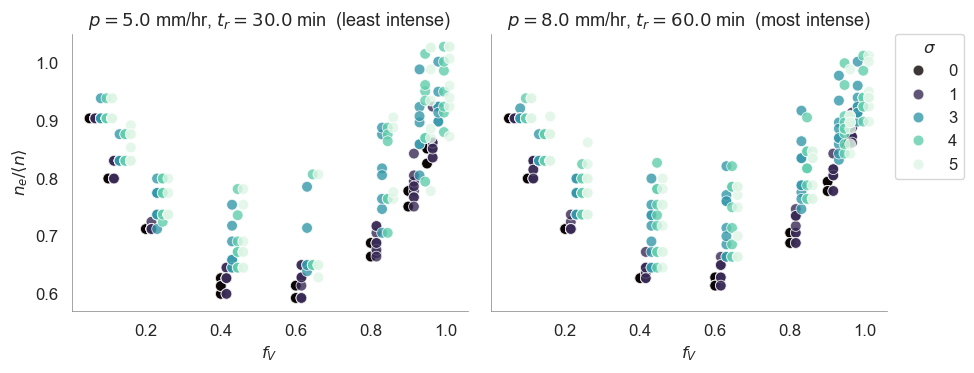

In [107]:
# effect_ratio vs fV — two panels: least and most intense storm, coloured by sigma
_cc_df = summary.query("hydro_err < 0.03").copy()
_cc_df['_d'] = _cc_df['p'].astype(float) * _cc_df['tr'].astype(float) / 60   # storm depth (mm)

# Pick the (p, tr) combos with min and max storm depth
_combos = _cc_df.groupby(['p', 'tr'])['_d'].first().reset_index()
_combos['_d'] = _combos['_d'].astype(float)
_lo = _combos.loc[_combos['_d'].idxmin(), ['p', 'tr']]
_hi = _combos.loc[_combos['_d'].idxmax(), ['p', 'tr']]
_storm_pairs = [(_lo['p'], _lo['tr']), (_hi['p'], _hi['tr'])]

# Sigma colour scale (mako)
_sigma_levels = sorted(_cc_df['sigma'].unique())
_mako = _cm.get_cmap('mako')
_sigma_norm = _mcolors.Normalize(vmin=0, vmax=max(_sigma_levels))
_sigma_palette = {s: _mako(_sigma_norm(s)) for s in _sigma_levels}

# Add a small offset between sigma values for visual separation
_sigma_offset = {s: i*0.015 for i, s in enumerate(_sigma_levels)}
for s in _sigma_levels:
    _cc_df.loc[_cc_df['sigma'] == s, 'fV'] += _sigma_offset[s]

fig_cc, axes_cc = plt.subplots(1, 2, figsize=(10, 4),
                               sharex=True, sharey=True, squeeze=False)

for ci, (p, tr) in enumerate(_storm_pairs):
    ax  = axes_cc[0, ci]
    sub = _cc_df[(_cc_df['p'] == p) & (_cc_df['tr'] == tr)]
    _show_leg = (ci == 1)
    _d_val = p * tr / 60
    sns.scatterplot(data=sub, x='fV', y='effect_ratio', ax=ax,
                    hue='sigma', hue_order=_sigma_levels,
                    palette=_sigma_palette, s=60, alpha=0.8,
                    legend=_show_leg)
    _intensity = 'most intense' if ci == 1 else 'least intense'
    ax.set_title(f"$p={p}$ mm/hr, $t_r={tr}$ min  ({_intensity})", fontsize=FS_TITLE)
    ax.set_xlabel(renameit('fV'), fontsize=FS_LABEL)
    ax.set_ylabel(renameit('effect_ratio') if ci == 0 else '', fontsize=FS_LABEL)
    ax.tick_params(labelsize=FS_TICK)
    if _show_leg:
        leg = ax.get_legend()
        if leg: leg.remove()
        hs, ls = ax.get_legend_handles_labels()
        ax.legend(hs, ls, title=renameit('sigma'), fontsize=FS_LEG,
                  title_fontsize=FS_LEG, loc='upper left',
                  bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()


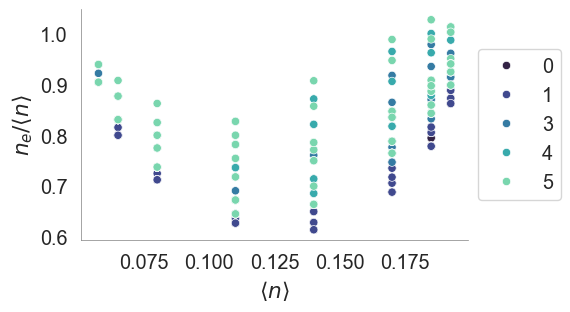

In [111]:
yfld = "effect_ratio"
xfld  = '<n>'
cfld = 'sigma'
g = sns.scatterplot(data = summary.query(query).rename(rename, axis = 1), 
                    x = rename[xfld], y = rename[yfld],   hue = rename[cfld], 
                    palette = mako(len(summary.query(query)[cfld].unique()))
                   )
g.legend(loc='center left',  bbox_to_anchor=(1.0, 0.5), ncol=1)    


In [112]:

# --- filter and make a working copy
query = "hydro_err < 0.05 and tr == 60 and p == 8"
subset = summary.query(query).copy()

# --- your deliberate shifts (since `tr == 60` is already in the query,
#     these apply to the whole subset)
subset["l"]     = subset["l"] + 10
subset["sigma"] = subset["sigma"].astype(int) 

# --- round σ to two decimals and force ordered categorical for clean ticks
subset["sigma"] = subset["sigma"].astype(float).round(2)
sigma_order = np.sort(subset["sigma"].dropna().unique())
subset["sigma"] = pd.Categorical(subset["sigma"], categories=sigma_order, ordered=True)

# --- rename columns for pretty axis labels (keeps numeric values intact)
subset = subset.rename(columns=rename)

xfld = renameit("sigma")          # r"$\sigma$"
yfld = renameit("effect_ratio")   # r"$n_e/\langle n \rangle$"
cfld = renameit("aniso")          # "anisotropic"


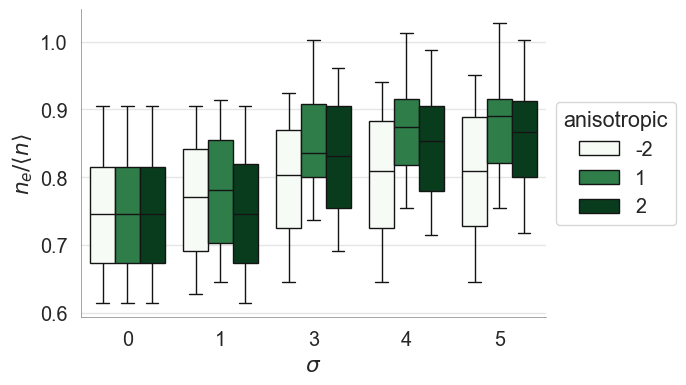

In [104]:

plt.figure(figsize=(6, 4))
ax = sns.boxplot(
    data=subset,
    x=xfld,
    y=yfld,
    hue=cfld,
    order=sigma_order,  # use the exact σ categories as tick order
    palette="Greens",
    dodge=True
)

# format ticks exactly as your rounded σ values
ax.set_xticklabels([f"{v:.0f}" for v in sigma_order])

# legend
ax.legend(loc="center left", title="anisotropic", bbox_to_anchor=(1.0, 0.5), ncol=1)
ax.set_xlabel(r"$\sigma$")
ax.set_ylabel(r"$n_e/\langle n \rangle$")
ax.grid(axis="y", alpha=0.2)
# TODO: remove

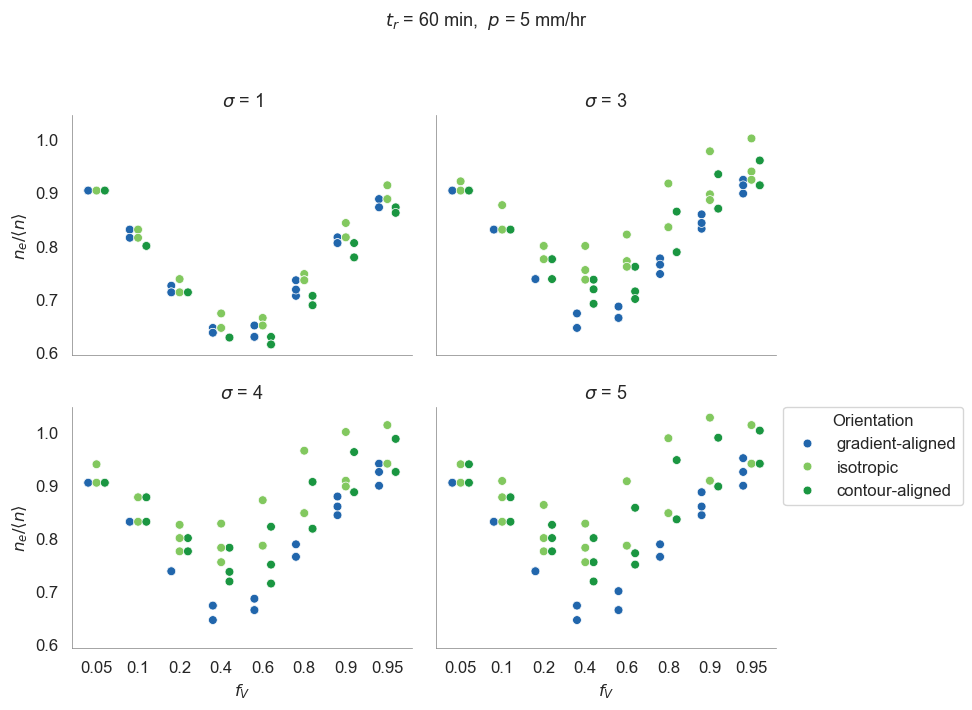

In [105]:
# effect_ratio vs fV — one panel per sigma value (σ>0), 2 rows × 2 cols
_ncols2 = 2
_df2 = summary.query("hydro_err < 0.05 and tr == 60 and p == 8 and sigma > 0").copy()
_sigma_vals = sorted(_df2['sigma'].unique())
_nrows2 = 2

# ── Same anisotropy labels + palette ─────────────────────────────────────────
_aniso_name2 = {v: ('gradient-aligned' if v < 0 else
                    'isotropic'        if v == 1 else
                    'contour-aligned') for v in sorted(_df2['aniso'].unique())}
_df2['_aniso_label'] = _df2['aniso'].map(_aniso_name2)
_label_order2 = [l for l in ['gradient-aligned', 'isotropic', 'contour-aligned']
                 if l in _df2['_aniso_label'].unique()]
_bg_cmap2 = _mcolors.LinearSegmentedColormap.from_list(
    'blue_green', ['#2166ac', '#92c5de', '#a6d96a', '#1a9641'])
_aniso_vals2 = sorted(_aniso_name2.keys())
_norm2 = _mcolors.Normalize(vmin=min(_aniso_vals2), vmax=max(_aniso_vals2))
_aniso_palette2 = {_aniso_name2[v]: _bg_cmap2(_norm2(v)) for v in _aniso_vals2}

# Fixed spacing between fV levels on the x-axis
_fv_levels = sorted(_df2['fV'].astype(float).unique())
_fv_step = 0.10
_fv_centers = {fv: i * _fv_step for i, fv in enumerate(_fv_levels)}
_df2['_fV_center'] = _df2['fV'].astype(float).map(_fv_centers)

# Fixed spacing between anisotropy categories around each fV center
_aniso_step = 0.02
_aniso_offsets = {
    lbl: (i - (len(_label_order2) - 1) / 2) * _aniso_step
    for i, lbl in enumerate(_label_order2)
}
_df2['_fV_plot'] = _df2['_fV_center'] + _df2['_aniso_label'].map(_aniso_offsets)

# Ticks show the original fV values, evenly spaced
_xticks = [_fv_centers[fv] for fv in _fv_levels]
_xticklabels = [f"{fv:.2g}" for fv in _fv_levels]

fig2, axes2 = plt.subplots(_nrows2, _ncols2, figsize=(10, 7),
                           sharey=True, sharex=True, squeeze=False)
axes2_flat = axes2.flatten()

for i, sigma in enumerate(_sigma_vals):
    ax = axes2_flat[i]
    _sub = _df2[_df2['sigma'] == sigma]
    _show_leg = (i == len(_sigma_vals) - 1)
    sns.scatterplot(_sub, x='_fV_plot', y='effect_ratio', ax=ax,
                    hue='_aniso_label', hue_order=_label_order2,
                    palette=_aniso_palette2, s=40, legend=_show_leg)
    ax.set_title(f"$\\sigma$ = {sigma:.3g}", fontsize=FS_TITLE)
    ax.set_xlabel(renameit('fV'), fontsize=FS_LABEL)
    ax.tick_params(labelsize=FS_TICK)
    ax.set_xticks(_xticks)
    ax.set_xticklabels(_xticklabels)
    ax.set_xlim(min(_xticks) - _fv_step * 0.6, max(_xticks) + _fv_step * 0.6)

# y-labels on left column only
for ri in range(_nrows2):
    axes2[ri, 0].set_ylabel(renameit('effect_ratio'), fontsize=FS_LABEL)
    for ci in range(1, _ncols2):
        axes2[ri, ci].set_ylabel('')

# Hide any unused axes
for ax in axes2_flat[len(_sigma_vals):]:
    ax.set_visible(False)

# Legend outside last panel
if axes2_flat[len(_sigma_vals) - 1].get_legend():
    axes2_flat[len(_sigma_vals) - 1].legend(
        title='Orientation', fontsize=FS_LEG, title_fontsize=FS_LEG,
        bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.suptitle("$t_r$ = 60 min,  $p$ = 5 mm/hr", y=1.02, fontsize=FS_TITLE)
plt.tight_layout()


## Sensitivity to storm characteristics

In [ ]:
summary['d'] = summary['p'] * summary['tr'] / 60
ax = sns.scatterplot(summary.query("fV == 0.6 and aniso == 1 "),
                     x='d', y='effect_ratio', hue='p', palette='coolwarm')
ax.set_xlabel(r"storm depth $d$ (cm)", fontsize=12)
ax.set_ylabel(rename.get('effect_ratio', r'$n_e/\langle n \rangle$'), fontsize=12)
ax.legend(title=r"$p$ (mm/hr)", fontsize=11, title_fontsize=11)
# sns.scatterplot(summary.query("fV == 0.6 and aniso == 1 and sigma ==5 "), x='p', y='effect_ratio')

_, _scratch, _ = _fig_dirs()
ax.get_figure().savefig(_os.path.join(_scratch, 'storm_depth_vs_effect_ratio.png'),
                        dpi=200, bbox_inches='tight')

# TODO : broader storm characteristics
# 

## Sensitivity to Reynolds number

In [ ]:
plt.figure(figsize = (7, 3))


yfld = "effect_ratio"
xfld  = 'Re_all'
cfld = "tr"
query ='hydro_err < 0.04 and Re_all < 400'
df = summary.query(query).rename(rename, axis = 1)
df = df.loc[:,~df.columns.duplicated()]

g = sns.scatterplot(data = df,
                    x = rename[xfld], y = rename[yfld],   hue = rename[cfld], 
                    palette =  mako(len(summary.query(query)[cfld].unique()))
                   )
g.legend(loc='center left', title =  rename[cfld],  bbox_to_anchor=(1.0, 0.5), ncol=1)    


## Illustrate hydrographs

In [ ]:
# To illustrate how well hydrograph matching works for a good fit, plot the hydrographs for one of the best-fitting simulations (e.g. hydro_err < 0.04).
fig, ax = plt.subplots(1, figsize=(10, 4))
sim = summary.query("hydro_err < 0.05 and hydro_err < 0.04").iloc[0]

ax.plot(sim.t/60, sim.hydro, label=f"$n_e$={sim.r_equiv:.2f}")
ax.plot(sim.t[:len(sim.equiv_hydro)]/60, sim.equiv_hydro, 
        label=r"$\langle n \rangle$" + f"={sim['<n>']:.2f}")

ax.legend()
ax.set_xlabel("Time (min)")
ax.set_ylabel("q (cm/hr)")


print(sim.name, sim.hydro_err)

## Illustrate vegetation patterns

In [ ]:
# 3D vegetation surface — side by side: σ=2 vs σ>4 vs uniform

fig = plt.figure(figsize=(12, 5))

# Right subplot: uniform roughness — real topography, single light-green colour
ax3 = fig.add_subplot(131, projection='3d')
sim3 = summary.iloc[0]
_light_green_cmap = _mcolors.LinearSegmentedColormap.from_list(
    'light_green', ['#a1d99b', '#a1d99b'])  # constant light green
plot_surface(
    sim3, 'veg',
    title='Uniform roughness',
    color=_light_green_cmap,
    ax=ax3,
    ucut=1,
    dcut=0,
    alpha=1.0,
    plot_veg=False
)



# Left subplot: sigma = 2
ax1 = fig.add_subplot(132, projection='3d')
sim1 = summary.query(" fV > 0.2 and fV < 0.5 and sigma == 1 and aniso > 1").iloc[0]
plot_surface(
    sim1, 'veg',
    title=r'Vegetation surface, $\sigma=2$ (no tracers)',
    color=cm.Greens,
    ax=ax1,
    ucut=1,
    dcut=0,
    alpha=1.0,
    plot_veg=False
)

# Middle subplot: sigma > 4
ax2 = fig.add_subplot(133, projection='3d')
sim2 = summary.query(" fV > 0.2 and fV < 0.5 and sigma > 4 and aniso > 1").iloc[0]
plot_surface(
    sim2, 'veg',
    title=r'Vegetation surface, $\sigma>4$ (no tracers)',
    color=cm.Greens,
    ax=ax2,
    ucut=1,
    dcut=0,
    alpha=1.0,
    plot_veg=False
)

plt.tight_layout()
plt.show()

In [ ]:
# Stacked hillslopes with varying green shades (dark → light)

_n_layers = 6
_z_spacing = 0.1  # vertical offset between layers

# Green shades from dark to light
_greens = ['#1a6b1a', '#2d8e2d', '#4aad4a', '#74c474', '#a1d99b', '#c7e9c0']

fig = plt.figure(figsize=(6, 6))
ax3 = fig.add_subplot(111, projection='3d')
ax3 = fix_3D_axes(ax3)

sim3 = summary.iloc[0]
_xc, _yc, _zc, _ = trim(sim3, sim3.veg, dcut=0, ucut=1)

for _i, _shade in enumerate(_greens):
    _z_offset = _i * _z_spacing
    _cmap_i = _mcolors.LinearSegmentedColormap.from_list(
        f'green_{_i}', [_shade, _shade])
    _colors_i = _cmap_i(np.ones_like(_zc) * 0.5)
    ax3.plot_surface(
        _xc, _yc, _zc + _z_offset,
        facecolors=_colors_i, rstride=1, cstride=1,
        linewidth=0, antialiased=True, shade=False, alpha=0.8
    )

ax3.view_init(25, 20)
_t = ax3.set_title('Stacked hillslopes (uniform roughness)', fontsize=14)
_t.set_y(0.9)
plt.tight_layout()
plt.show()

In [ ]:
# Stacked hillslopes with varying green shades (dark → light)

_n_layers = 6
_z_spacing = 0.5  # vertical offset between layers

# Green shades from dark to light
_greens = ['#1a6b1a', '#2d8e2d', '#4aad4a', '#74c474', '#a1d99b', '#c7e9c0']

fig = plt.figure(figsize=(6, 6))
ax3 = fig.add_subplot(111, projection='3d')
ax3 = fix_3D_axes(ax3)

sim3 = summary.iloc[0]
_xc, _yc, _zc, _ = trim(sim3, sim3.veg, dcut=0, ucut=1)



ax3.view_init(20, 20)

for _i, _shade in enumerate(_greens):
    _z_offset = _i * _z_spacing
    _scale = 1.2 - _i * 0.0

    # Anchor scaling to one edge (e.g. the upslope/ridge edge)
    _xc_anchor = _xc.max()   # or .max() depending on slope orientation
    _yc_anchor = _yc.max()

    _xc_scaled = _xc_anchor + (_xc - _xc_anchor) * _scale
    _yc_scaled = _yc_anchor + (_yc - _yc_anchor) * _scale

    _cmap_i = _mcolors.LinearSegmentedColormap.from_list(
        f'green_{_i}', [_shade, _shade])
    _colors_i = _cmap_i(np.ones_like(_zc) * 0.5)
    ax3.plot_surface(
        _xc_scaled, _yc_scaled, _zc + _z_offset,
        facecolors=_colors_i, rstride=1, cstride=1,
        linewidth=0, antialiased=True, shade=False, alpha=0.8
    )

In [ ]:
# 3D vegetation surface only — side by side: σ=2 vs σ>4 vs uniform

# Illustrate library of vegetation surfaces by plotting the same topography multiple times with varying green shades, simulating a "stacked hillslope" effect. For each spatially varying roughness case, an 'equivalent' uniform roughness case is determined through calibration.

fig = plt.figure(figsize=(10, 7))

# Right subplot: uniform roughness — real topography, single light-green colour
ax3 = fig.add_subplot(131, projection='3d')
sim3 = summary.iloc[0]
_xc, _yc, _zc, _ = trim(sim3, sim3.veg, dcut=0, ucut=1)

_n_layers = 5
_z_spacing = 0.5  # vertical offset between layers

# Green shades from dark to light
_greens = ['#1a6b1a', '#2d8e2d', '#4aad4a', '#74c474', '#a1d99b', '#c7e9c0']
_greens = ['#1a6b1a', '#2d8e2d', '#4aad4a', '#a1d99b', '#c7e9c0']


for _i, _shade in enumerate(_greens):
    _z_offset = _i * _z_spacing
    _scale = 1.2 - _i * 0.02

    # Anchor scaling to one edge (e.g. the upslope/ridge edge)
    _xc_anchor = _xc.max()   # or .max() depending on slope orientation
    _yc_anchor = _yc.max()

    _xc_scaled = _xc_anchor + (_xc - _xc_anchor) * _scale
    _yc_scaled = _yc_anchor + (_yc - _yc_anchor) * _scale

    _cmap_i = _mcolors.LinearSegmentedColormap.from_list(
        f'green_{_i}', [_shade, _shade])
    _colors_i = _cmap_i(np.ones_like(_zc) * 0.5)
    ax3.plot_surface(
        _xc_scaled, _yc_scaled, _zc + _z_offset,
        facecolors=_colors_i, rstride=1, cstride=1,
        linewidth=0, edgecolor='none', antialiased=True, shade=False, alpha=0.8
    )

ax3 = fix_3D_axes(ax3)
ax3.view_init(25, 20)
ax3.set_title('Uniform roughness', fontsize=14)

# Left subplot: sigma = 2
ax1 = fig.add_subplot(132, projection='3d')
sim1 = summary.query(" fV > 0.2 and fV < 0.5 and sigma == 1 and aniso > 1").iloc[0]
plot_surface(
    sim1, 'veg',
    title=r'Vegetation surface, $\sigma=2$',
    color=cm.Greens,
    ax=ax1,
    ucut=1,
    dcut=0,
    alpha=1.0,
    plot_veg=False
)
print (ax1.get_zlim())
ax1.set_zlim([ax1.get_zlim()[0], ax1.get_zlim()[1]*1.6])


# Middle subplot: sigma > 4
ax2 = fig.add_subplot(133, projection='3d')
sim2 = summary.query(" fV > 0.2 and fV < 0.5 and sigma > 4 and aniso > 1").iloc[0]
plot_surface(
    sim2, 'veg',
    title=r'Vegetation surface, $\sigma>4$ ',
    color=cm.Greens,
    ax=ax2,
    ucut=1,
    dcut=0,
    alpha=1.0,
    plot_veg=False
)
ax2.set_zlim([ax2.get_zlim()[0], ax2.get_zlim()[1]*1.6])

plt.tight_layout()
plt.show()